# Exploratory Data Analysis

---

1. Import Libraries
2. Loading data with Pandas
3. Descriptive statistics of data
4. Data visualization
5. Feature Engineering
6. Model Training
7. Model Evaluation
---

## 1. Import Libraries

In [469]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [470]:
YELLOW = "#FFD700"
BLUE = "#1E90FF"

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = True

## 2. LOAD THE DATASET

In [472]:
df = pd.read_csv("aedc_cx_dataset_1000.csv")

df.head()

,Name,Customer_ID,Account_Number,Meter_Number,Age,Location,Income,Purchase_Frequency,Purchase_History,Churn_Status,...,Service_Charge,Debt_Arrears,Previous_Meter_Reading,Current_Meter_Reading,Energy_Consumption,Billing_Cycle,Billing_Accuracy,Power_Outage_Frequency,Power_Outage_Duration_Hours,Service_Usage
0,Victoria Huffman,CUST500000,AEDC100000,MTR200000,37,"Jabi, Abuja, Nigeria",67628,10,46405.95,No,...,1520.20,12721.44,7243,7309,66,Jun-2025,0.99,1,1.88,685.79
1,Stephanie Mendoza,CUST500001,AEDC100001,MTR200001,30,"Jabi, Abuja, Nigeria",115222,2,7270.59,Yes,...,1317.37,12673.51,6041,6116,75,Jan-2025,0.86,3,3.82,128.68
2,Ashley Meadows,CUST500002,AEDC100002,MTR200002,24,"Kurudu, Abuja, Nigeria",30000,6,9535.33,No,...,748.70,23076.67,3603,3616,13,Jun-2025,0.90,4,4.62,20.00
3,Christina Washington,CUST500003,AEDC100003,MTR200003,30,"Jabi, Abuja, Nigeria",97539,9,67072.04,No,...,2210.31,8620.57,6930,7005,75,Feb-2025,0.92,12,7.38,613.26
4,Catherine Castillo,CUST500004,AEDC100004,MTR200004,25,"Gwarinpa, Abuja, Nigeria",70877,9,20027.24,No,...,2298.08,6114.79,3557,3578,21,Jun-2025,1.00,2,2.23,144.24


With the aedc_cx_dataset, we have a mix of numeric and categorical data, which we will need to transform before modelling later

## 3. Descriptive statistics of data

In [475]:
df.shape

(1000, 33)

In [476]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Name                           1000 non-null   object 
 1   Customer_ID                    1000 non-null   object 
 2   Account_Number                 1000 non-null   object 
 3   Meter_Number                   1000 non-null   object 
 4   Age                            1000 non-null   int64  
 5   Location                       1000 non-null   object 
 6   Income                         1000 non-null   int64  
 7   Purchase_Frequency             1000 non-null   int64  
 8   Purchase_History               1000 non-null   float64
 9   Churn_Status                   1000 non-null   object 
 10  Customer_Satisfaction_Score    1000 non-null   float64
 11  Average_Resolution_Time_Hours  1000 non-null   float64
 12  Complaint_Frequency            1000 non-null   in

We can see that there is are missing values for 'Token (empty for Postpaid)' over 489.

In [478]:
df.describe()

,Age,Income,Purchase_Frequency,Purchase_History,Customer_Satisfaction_Score,Average_Resolution_Time_Hours,Complaint_Frequency,Amount_Paid,Units_Purchased,VAT,Service_Charge,Debt_Arrears,Previous_Meter_Reading,Current_Meter_Reading,Energy_Consumption,Billing_Accuracy,Power_Outage_Frequency,Power_Outage_Duration_Hours,Service_Usage
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,37.140000,78088.813000,7.520000,51371.405570,3.864770,31.054800,2.084000,6518.741120,74.687710,488.905630,1376.499990,21959.559000,4518.524000,4592.719000,74.195000,0.912680,4.581000,8.161420,557.726670
std,10.100318,60842.158741,2.950645,58033.862788,0.650801,11.889321,1.899619,6106.074609,71.407815,457.955454,631.078474,18214.764709,2025.375363,2027.280116,71.409203,0.057178,2.863152,6.406561,598.490724
min,18.000000,30000.000000,1.000000,2244.460000,1.000000,2.000000,0.000000,777.950000,7.180000,58.350000,307.060000,38.240000,1004.000000,1037.000000,7.000000,0.720000,0.000000,0.000000,20.000000
25%,30.000000,38136.500000,5.000000,19334.442500,3.460000,22.917500,0.000000,2780.552500,31.140000,208.542500,826.185000,9245.887500,2726.750000,2803.000000,31.000000,0.870000,2.000000,3.387500,192.050000
50%,37.000000,61143.000000,8.000000,34846.425000,3.910000,30.555000,2.000000,4592.895000,51.285000,344.465000,1340.275000,18170.375000,4434.500000,4488.500000,51.000000,0.920000,5.000000,6.885000,376.545000
75%,44.000000,94991.750000,9.000000,64327.707500,4.410000,38.632500,3.000000,8163.877500,94.125000,612.287500,1921.250000,26786.162500,6285.500000,6387.000000,94.000000,0.960000,6.250000,11.875000,713.477500
max,65.000000,728308.000000,15.000000,820848.950000,4.940000,71.450000,11.000000,79107.720000,725.970000,5933.080000,2495.030000,79922.200000,7993.000000,8194.000000,725.000000,1.000000,14.000000,33.520000,5000.000000


#### CHECK MISSING VALUES

In [480]:
df.isnull().sum()

Name                               0
Customer_ID                        0
Account_Number                     0
Meter_Number                       0
Age                                0
Location                           0
Income                             0
Purchase_Frequency                 0
Purchase_History                   0
Churn_Status                       0
Customer_Satisfaction_Score        0
Average_Resolution_Time_Hours      0
Complaint_Frequency                0
Transaction_DateTime               0
Transaction_Reference              0
Receipt_Number                     0
Payment_Type                       0
Meter_Type                         0
Tariff_Class                       0
Amount_Paid                        0
Units_Purchased                    0
Token                            489
VAT                                0
Service_Charge                     0
Debt_Arrears                       0
Previous_Meter_Reading             0
Current_Meter_Reading              0
E

we can see that Token have about 489 value missing

In [482]:
(df.isnull().sum() / len(df)) * 100

Name                              0.0
Customer_ID                       0.0
Account_Number                    0.0
Meter_Number                      0.0
Age                               0.0
Location                          0.0
Income                            0.0
Purchase_Frequency                0.0
Purchase_History                  0.0
Churn_Status                      0.0
Customer_Satisfaction_Score       0.0
Average_Resolution_Time_Hours     0.0
Complaint_Frequency               0.0
Transaction_DateTime              0.0
Transaction_Reference             0.0
Receipt_Number                    0.0
Payment_Type                      0.0
Meter_Type                        0.0
Tariff_Class                      0.0
Amount_Paid                       0.0
Units_Purchased                   0.0
Token                            48.9
VAT                               0.0
Service_Charge                    0.0
Debt_Arrears                      0.0
Previous_Meter_Reading            0.0
Current_Mete

also about 48.9% missing value 

Token column → keep empty for Postpaid (valid)

#### CONVERT DATE COLUMN TO DATETIME

In [486]:
df["Transaction_DateTime"] = pd.to_datetime(df["Transaction_DateTime"])

df["Year"] = df["Transaction_DateTime"].dt.year
df["Month"] = df["Transaction_DateTime"].dt.month
df["Month_Name"] = df["Transaction_DateTime"].dt.month_name()
df["Date"] = df["Transaction_DateTime"].dt.date

df.head()

,Name,Customer_ID,Account_Number,Meter_Number,Age,Location,Income,Purchase_Frequency,Purchase_History,Churn_Status,...,Energy_Consumption,Billing_Cycle,Billing_Accuracy,Power_Outage_Frequency,Power_Outage_Duration_Hours,Service_Usage,Year,Month,Month_Name,Date
0,Victoria Huffman,CUST500000,AEDC100000,MTR200000,37,"Jabi, Abuja, Nigeria",67628,10,46405.95,No,...,66,Jun-2025,0.99,1,1.88,685.79,2025,11,November,2025-11-12
1,Stephanie Mendoza,CUST500001,AEDC100001,MTR200001,30,"Jabi, Abuja, Nigeria",115222,2,7270.59,Yes,...,75,Jan-2025,0.86,3,3.82,128.68,2025,4,April,2025-04-07
2,Ashley Meadows,CUST500002,AEDC100002,MTR200002,24,"Kurudu, Abuja, Nigeria",30000,6,9535.33,No,...,13,Jun-2025,0.90,4,4.62,20.00,2025,10,October,2025-10-27
3,Christina Washington,CUST500003,AEDC100003,MTR200003,30,"Jabi, Abuja, Nigeria",97539,9,67072.04,No,...,75,Feb-2025,0.92,12,7.38,613.26,2025,9,September,2025-09-13
4,Catherine Castillo,CUST500004,AEDC100004,MTR200004,25,"Gwarinpa, Abuja, Nigeria",70877,9,20027.24,No,...,21,Jun-2025,1.00,2,2.23,144.24,2025,10,October,2025-10-06


The convertion was made so we can prefrom
monthly trends
yearly trends
forecasting analysis

## 4. Data visualization

#### CHECK CHURN DISTRIBUTION

In [490]:
df["Churn_Status"].value_counts()

Churn_Status
No     749
Yes    251
Name: count, dtype: int64

#### Churn Percentage

In [492]:
(df["Churn_Status"].value_counts(normalize=True) * 100)

Churn_Status
No     74.9
Yes    25.1
Name: proportion, dtype: float64

#### VISUALIZE CHURN STATUS

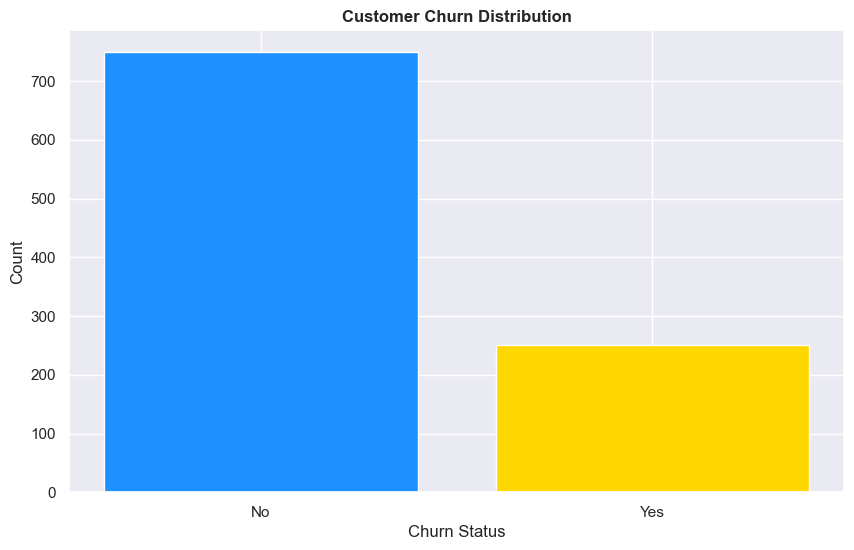

In [494]:
churn_counts = df["Churn_Status"].value_counts()

plt.bar(churn_counts.index, churn_counts.values, color=[BLUE, YELLOW])
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Count")
plt.show()

AEDC retains most customers that is why "No" is much higher than "Yes".

#### DISTRIBUTION OF INCOME

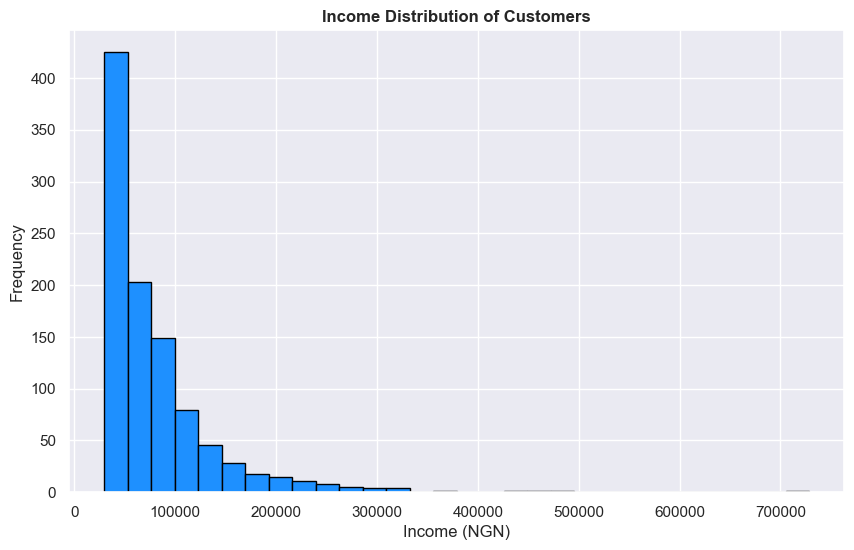

In [497]:
plt.hist(df["Income"], bins=30, color=BLUE, edgecolor="black")
plt.title("Income Distribution of Customers")
plt.xlabel("Income (NGN)")
plt.ylabel("Frequency")
plt.show()

Skewed distribution means most customers earn moderate income.
Few high-income customers exist (right tail).

#### DISTRIBUTION OF PURCHASE HISTORY

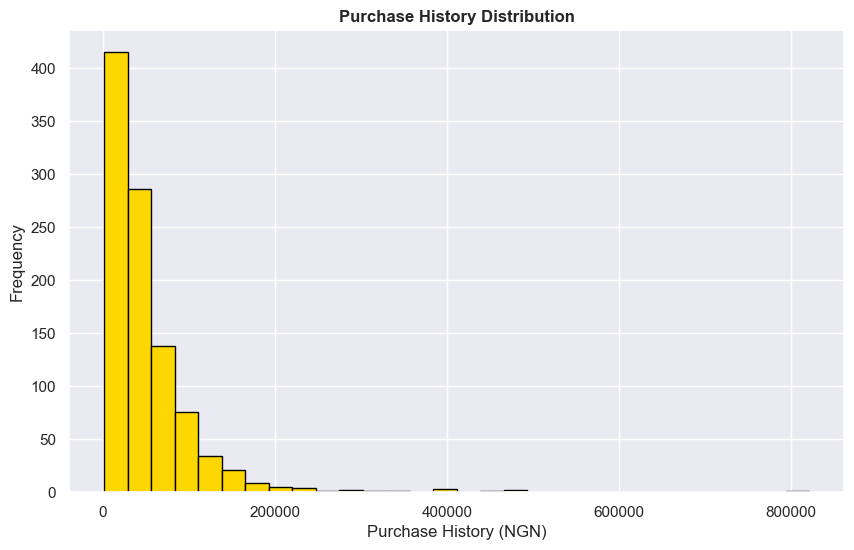

In [500]:
plt.hist(df["Purchase_History"], bins=30, color=YELLOW, edgecolor="black")
plt.title("Purchase History Distribution")
plt.xlabel("Purchase History (NGN)")
plt.ylabel("Frequency")
plt.show()

Higher purchase history indicates:

high consumption
frequent purchases
high-value customer group

## 10. VISUALIZE POWER OUTAGE FREQUENCY

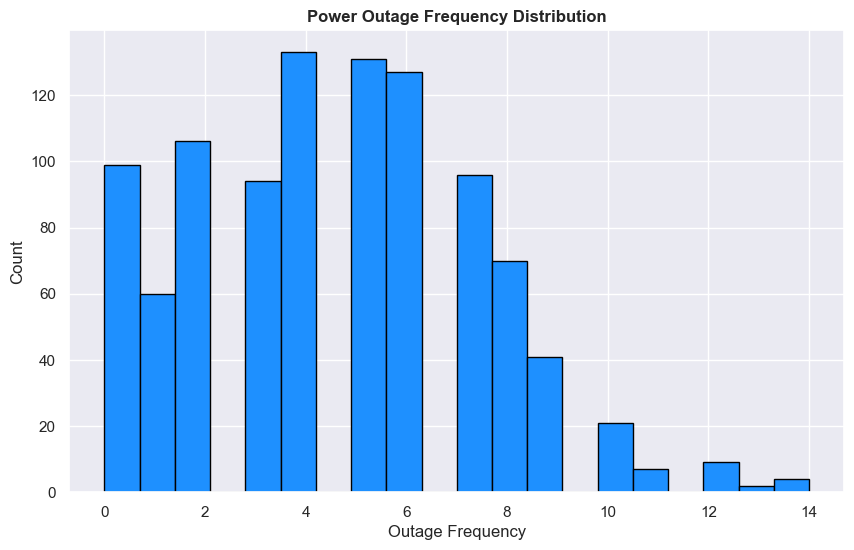

In [503]:
plt.hist(df["Power_Outage_Frequency"], bins=20, color=BLUE, edgecolor="black")
plt.title("Power Outage Frequency Distribution")
plt.xlabel("Outage Frequency")
plt.ylabel("Count")
plt.show()

most customers fall in 3–7 outages means the:

service is unstable

possible churn risk

#### VISUALIZE POWER OUTAGE DURATION

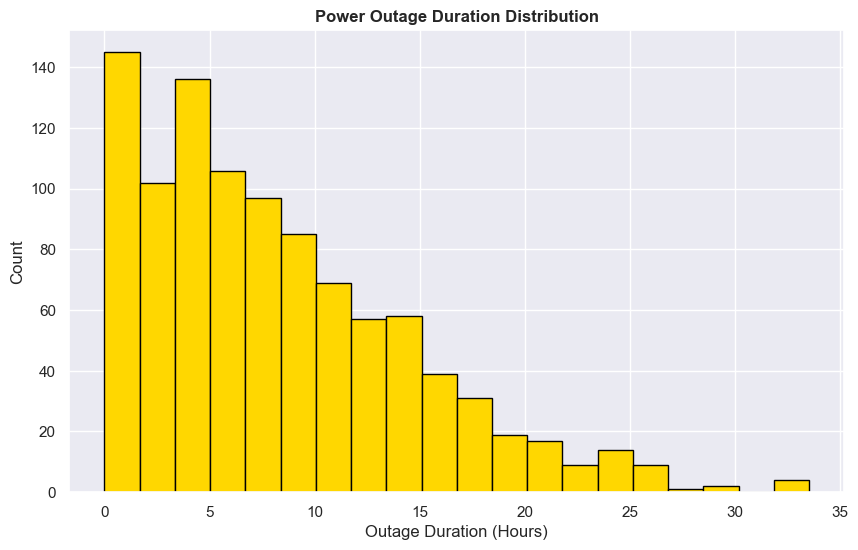

In [506]:
plt.hist(df["Power_Outage_Duration_Hours"], bins=20, color=YELLOW, edgecolor="black")
plt.title("Power Outage Duration Distribution")
plt.xlabel("Outage Duration (Hours)")
plt.ylabel("Count")
plt.show()

Longer outage duration often leads to:

dissatisfaction

increased complaints

churn risk

#### SERVICE USAGE DISTRIBUTION

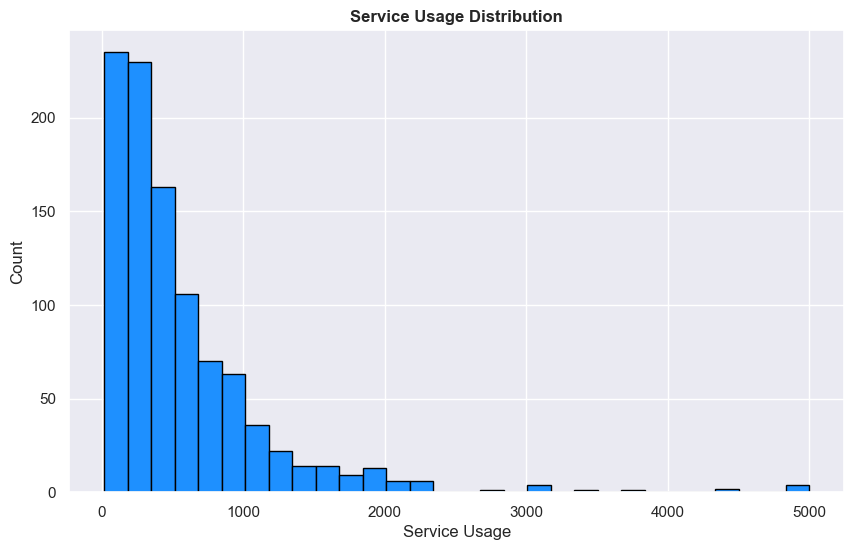

In [509]:
plt.hist(df["Service_Usage"], bins=30, color=BLUE, edgecolor="black")
plt.title("Service Usage Distribution")
plt.xlabel("Service Usage")
plt.ylabel("Count")
plt.show()

High service usage customers are the most profitable.
    
They should be prioritized for retention.

#### CUSTOMER SATISFACTION SCORE DISTRIBUTION

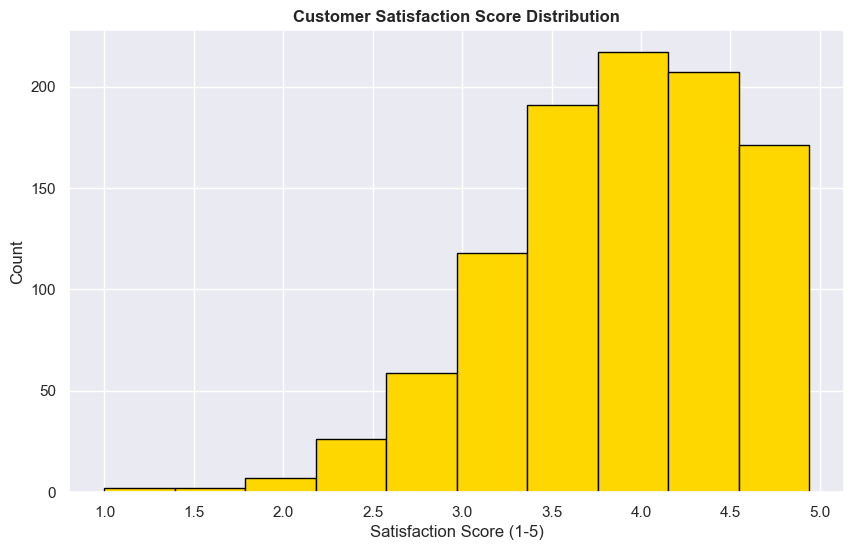

In [543]:
plt.hist(df["Customer_Satisfaction_Score"], bins=10, color=YELLOW, edgecolor="black")
plt.title("Customer Satisfaction Score Distribution")
plt.xlabel("Satisfaction Score (1-5)")
plt.ylabel("Count")
plt.show()

If most scores fall between 2–4:

it suggests moderate satisfaction levels

very low scores indicate churn risk

#### COMPLAINT FREQUENCY DISTRIBUTION

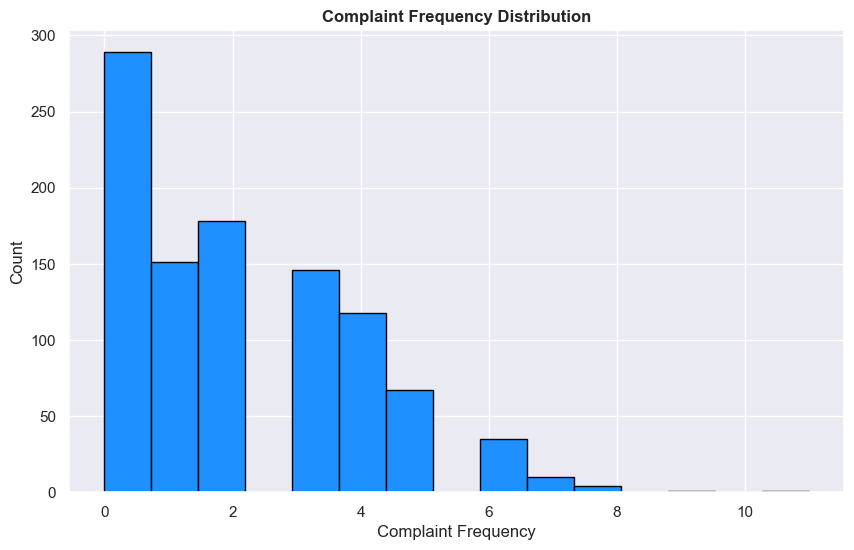

In [545]:
plt.hist(df["Complaint_Frequency"], bins=15, color=BLUE, edgecolor="black")
plt.title("Complaint Frequency Distribution")
plt.xlabel("Complaint Frequency")
plt.ylabel("Count")
plt.show()

In [ ]:
Customers with frequent complaints are more likely to churn.
    
Complaint frequency is a key CX churn driver.

#### AVERAGE RESOLUTION TIME DISTRIBUTION

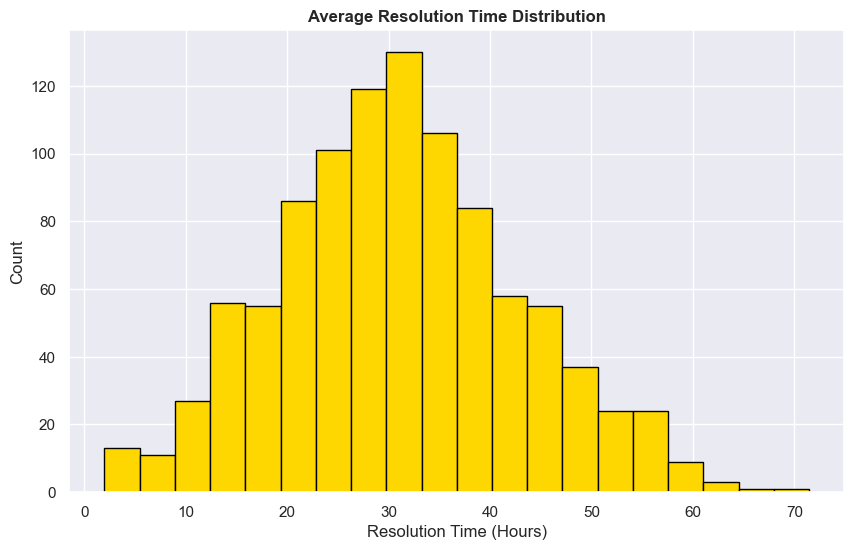

In [547]:
plt.hist(df["Average_Resolution_Time_Hours"], bins=20, color=YELLOW, edgecolor="black")
plt.title("Average Resolution Time Distribution")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Count")
plt.show()

Higher resolution times indicate poor customer support response.
    
Longer resolution times → reduced satisfaction

#### CHURN VS INCOME VISUALIZATION

In [537]:
df.groupby("Churn_Status")["Income"].mean()

Churn_Status
No     79863.631509
Yes    72792.641434
Name: Income, dtype: float64

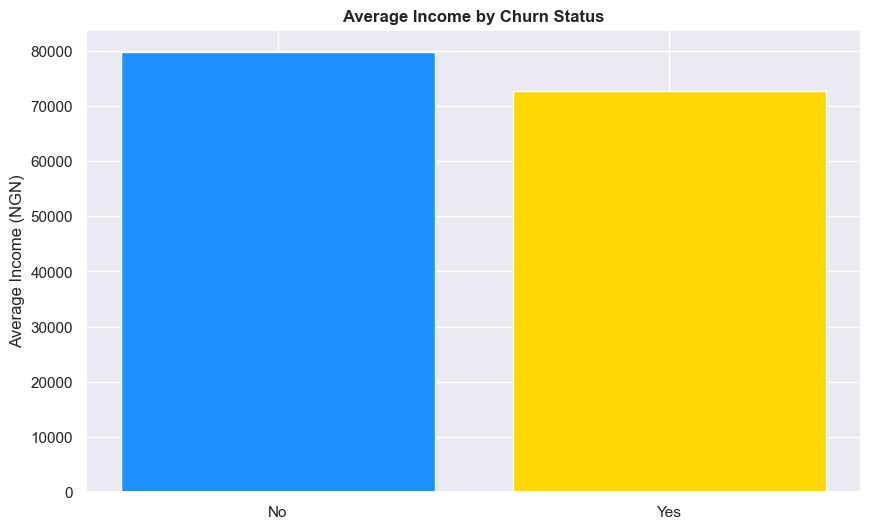

Churn_Status
No     79863.631509
Yes    72792.641434
Name: Income, dtype: float64

In [539]:
income_churn = df.groupby("Churn_Status")["Income"].mean()

plt.bar(income_churn.index, income_churn.values, color=[BLUE, YELLOW])
plt.title("Average Income by Churn Status")
plt.ylabel("Average Income (NGN)")
plt.show()

income_churn

If churned customers earn less → financial struggles increase churn risk.

If churned customers earn more → dissatisfaction may be main driver.

#### CHURN VS PURCHASE HISTORY

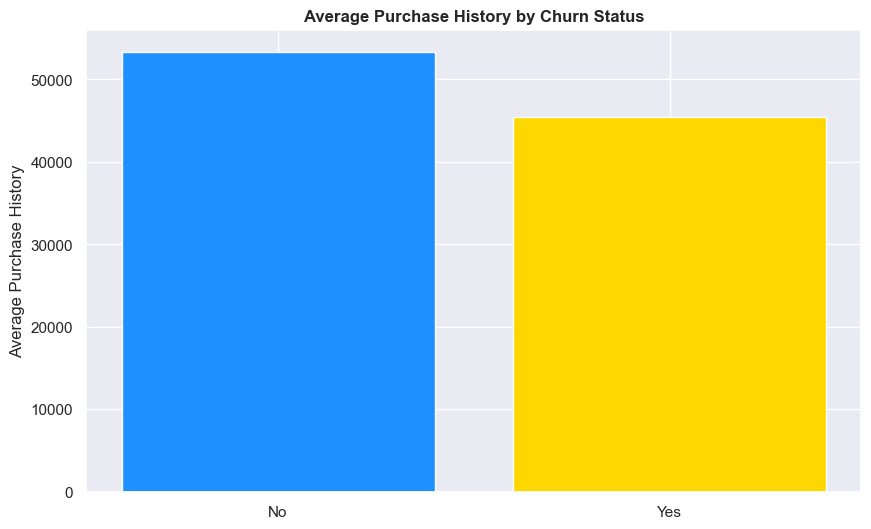

Churn_Status
No     53354.437049
Yes    45453.913227
Name: Purchase_History, dtype: float64

In [553]:
purchase_churn = df.groupby("Churn_Status")["Purchase_History"].mean()

plt.bar(purchase_churn.index, purchase_churn.values, color=[BLUE, YELLOW])
plt.title("Average Purchase History by Churn Status")
plt.ylabel("Average Purchase History")
plt.show()

purchase_churn

If churned customers have lower purchase history:

low engagement customers churn easily.
    
high purchase customers are more loyal.

#### CHURN VS POWER OUTAGE FREQUENCY

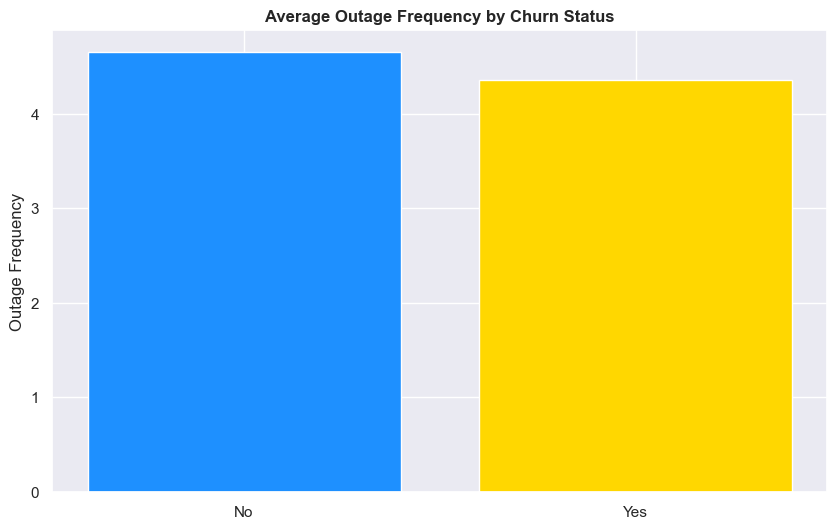

Churn_Status
No     4.656876
Yes    4.354582
Name: Power_Outage_Frequency, dtype: float64

In [555]:
outage_churn = df.groupby("Churn_Status")["Power_Outage_Frequency"].mean()

plt.bar(outage_churn.index, outage_churn.values, color=[BLUE, YELLOW])
plt.title("Average Outage Frequency by Churn Status")
plt.ylabel("Outage Frequency")
plt.show()

outage_churn

Higher outages among churned customers suggests:

poor service reliability is a churn trigger.

#### CHURN VS OUTAGE DURATION

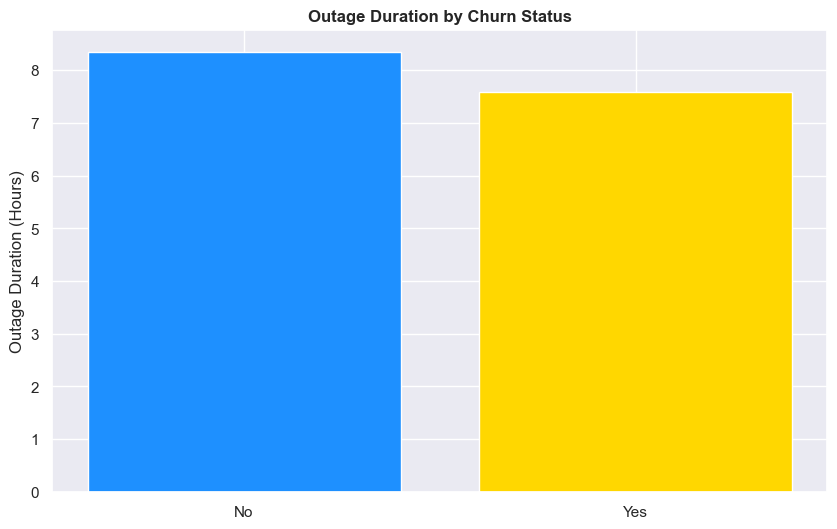

Churn_Status
No     8.351268
Yes    7.594900
Name: Power_Outage_Duration_Hours, dtype: float64

In [558]:
duration_churn = df.groupby("Churn_Status")["Power_Outage_Duration_Hours"].mean()

plt.bar(duration_churn.index, duration_churn.values, color=[BLUE, YELLOW])
plt.title("Outage Duration by Churn Status")
plt.ylabel("Outage Duration (Hours)")
plt.show()

duration_churn

Longer outage duration increases dissatisfaction, complaints, and churn.

### ENERGY CONSUMPTION ANALYSIS (YEARLY & MONTHLY)

#### ENERGY CONSUMPTION DISTRIBUTION

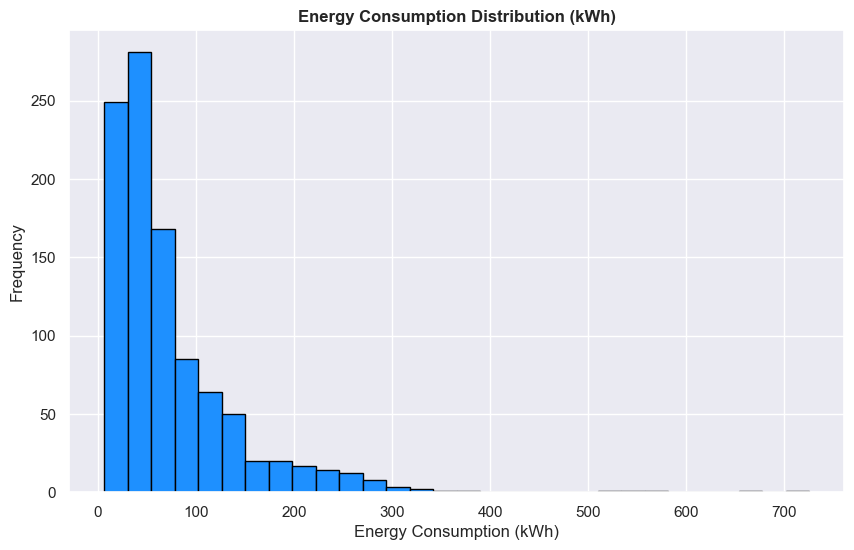

In [560]:
plt.hist(df["Energy_Consumption"], bins=30, color=BLUE, edgecolor="black")
plt.title("Energy Consumption Distribution (kWh)")
plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Frequency")
plt.show()

This shows:

most customers are low consumers (residential)

some are high consumers (business/commercial)

### MONTHLY TOTAL CONSUMPTION TREND

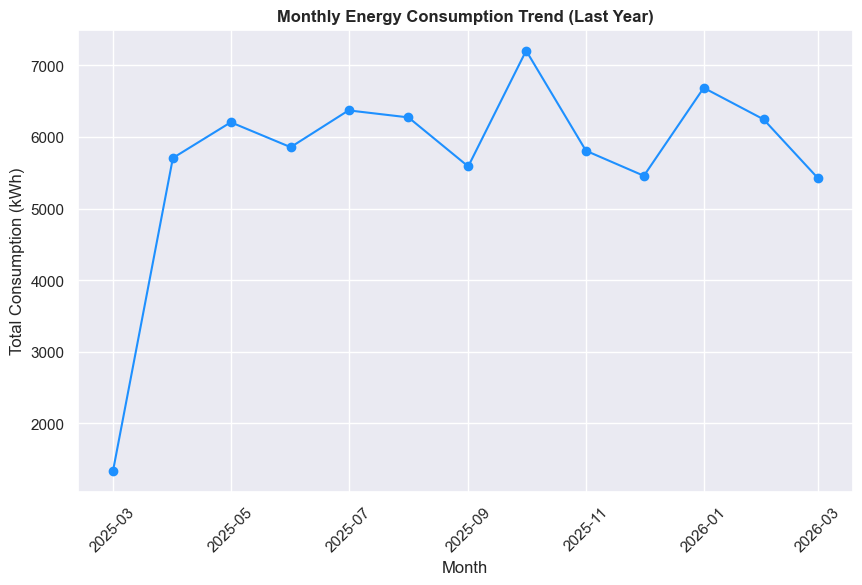

,Year,Month,Energy_Consumption,Date
0,2025,3,1341,2025-03-01
1,2025,4,5708,2025-04-01
2,2025,5,6207,2025-05-01
3,2025,6,5859,2025-06-01
4,2025,7,6373,2025-07-01
5,2025,8,6275,2025-08-01
6,2025,9,5590,2025-09-01
7,2025,10,7207,2025-10-01
8,2025,11,5809,2025-11-01
9,2025,12,5459,2025-12-01


In [562]:
monthly_consumption = df.groupby(["Year", "Month"])["Energy_Consumption"].sum().reset_index()

monthly_consumption["Date"] = pd.to_datetime(
    monthly_consumption["Year"].astype(str) + "-" + monthly_consumption["Month"].astype(str)
)

plt.plot(monthly_consumption["Date"], monthly_consumption["Energy_Consumption"], color=BLUE, marker="o")
plt.title("Monthly Energy Consumption Trend (Last Year)")
plt.xlabel("Month")
plt.ylabel("Total Consumption (kWh)")
plt.xticks(rotation=45)
plt.show()

monthly_consumption

Peaks could mean festive months or high demand season.
    
Drops could indicate fewer purchases or outage-heavy periods.

#### FORECAST ENERGY CONSUMPTION 

We can use a basic forecasting approach like moving average.

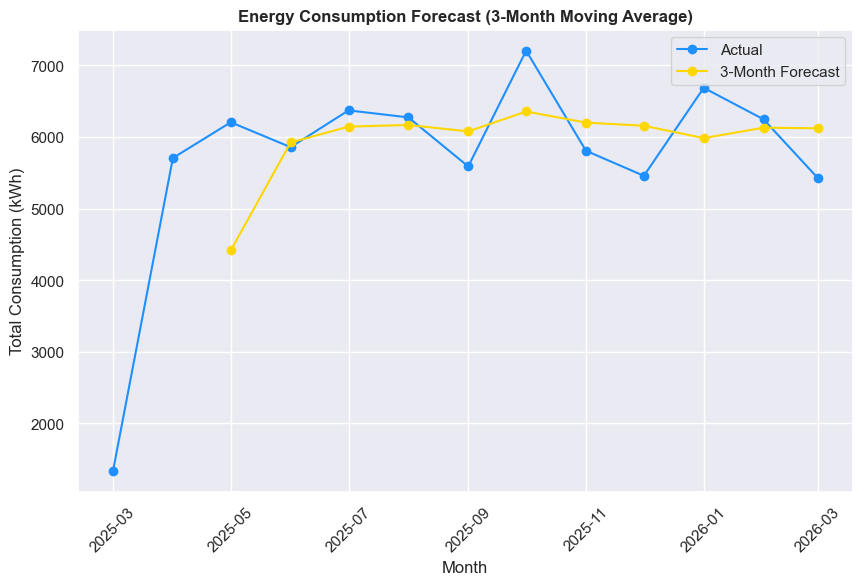

In [564]:
monthly_consumption["Forecast_3MA"] = monthly_consumption["Energy_Consumption"].rolling(3).mean()

plt.plot(monthly_consumption["Date"], monthly_consumption["Energy_Consumption"], color=BLUE, marker="o", label="Actual")
plt.plot(monthly_consumption["Date"], monthly_consumption["Forecast_3MA"], color=YELLOW, marker="o", label="3-Month Forecast")

plt.title("Energy Consumption Forecast (3-Month Moving Average)")
plt.xlabel("Month")
plt.ylabel("Total Consumption (kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

This is a simple forecast model:

it smoothens spikes

shows expected next consumption trend

#### CALCULATE MARGINS (SIMULATION)
Since dataset does not contain AEDC cost price, we assume:

Selling price per unit = Amount Paid / Units Purchased

Cost per unit (assumed) = ₦40

Margin = Revenue - Cost

Margin Distribution

In [566]:
df["Estimated_Cost"] = df["Units_Purchased"] * 40
df["Margin"] = df["Amount_Paid"] - df["Estimated_Cost"]

df[["Amount_Paid", "Units_Purchased", "Estimated_Cost", "Margin"]].head()

,Amount_Paid,Units_Purchased,Estimated_Cost,Margin
0,4147.93,66.78,2671.2,1476.73
1,4218.52,75.52,3020.8,1197.72
2,1291.47,13.51,540.4,751.07
3,8881.58,75.97,3038.8,5842.78
4,2642.77,21.71,868.4,1774.37


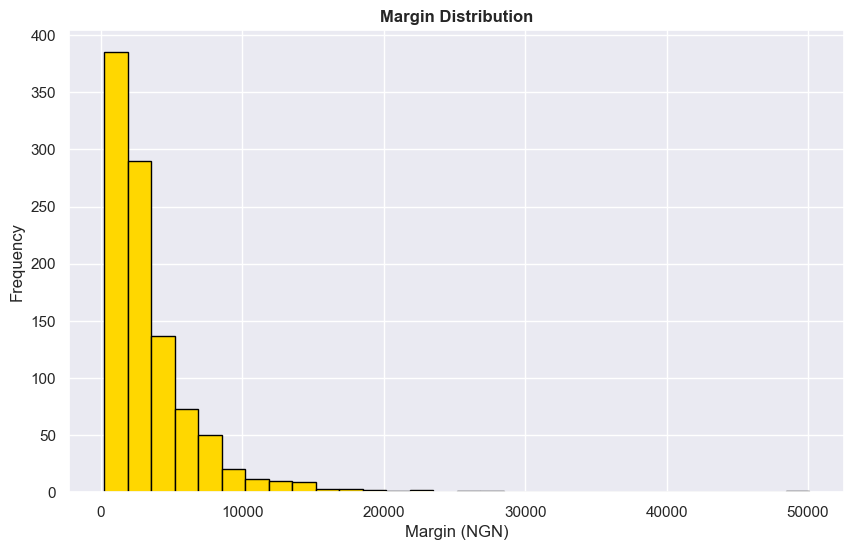

In [568]:
plt.hist(df["Margin"], bins=30, color=YELLOW, edgecolor="black")
plt.title("Margin Distribution")
plt.xlabel("Margin (NGN)")
plt.ylabel("Frequency")
plt.show()

This helps AEDC understand profitability across customers.

#### SUBSCRIBED POWER (SIMULATION FEATURE)

We estimate subscribed power based on service usage.

In [570]:
df["Subscribed_Power_kVA"] = np.where(df["Service_Usage"] > 2000, 15,
                             np.where(df["Service_Usage"] > 1200, 10,
                             np.where(df["Service_Usage"] > 700, 5, 2)))

df["Subscribed_Power_kVA"].value_counts()

Subscribed_Power_kVA
2     742
5     162
10     71
15     25
Name: count, dtype: int64

Visualization

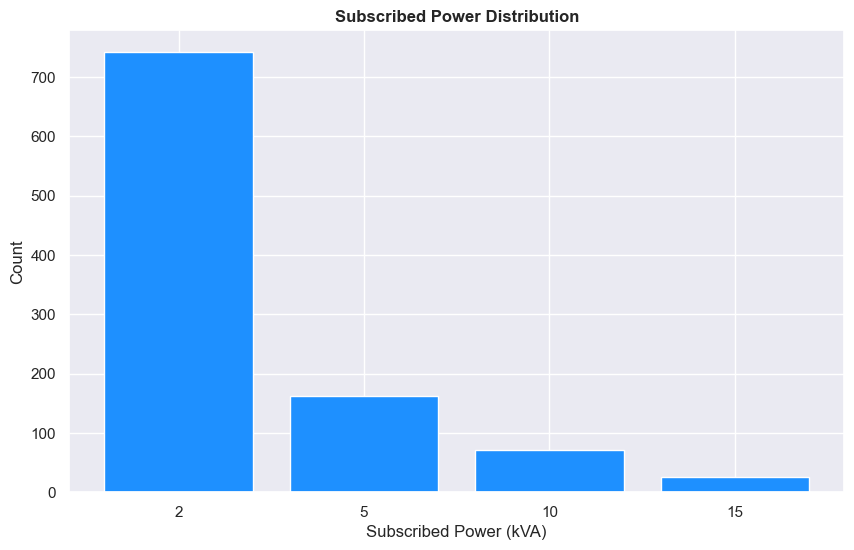

In [572]:
sub_counts = df["Subscribed_Power_kVA"].value_counts()

plt.bar(sub_counts.index.astype(str), sub_counts.values, color=BLUE)
plt.title("Subscribed Power Distribution")
plt.xlabel("Subscribed Power (kVA)")
plt.ylabel("Count")
plt.show()

2kVA customers = small households

15kVA customers = high-value businesses

#### CORRELATION HEATMAP 

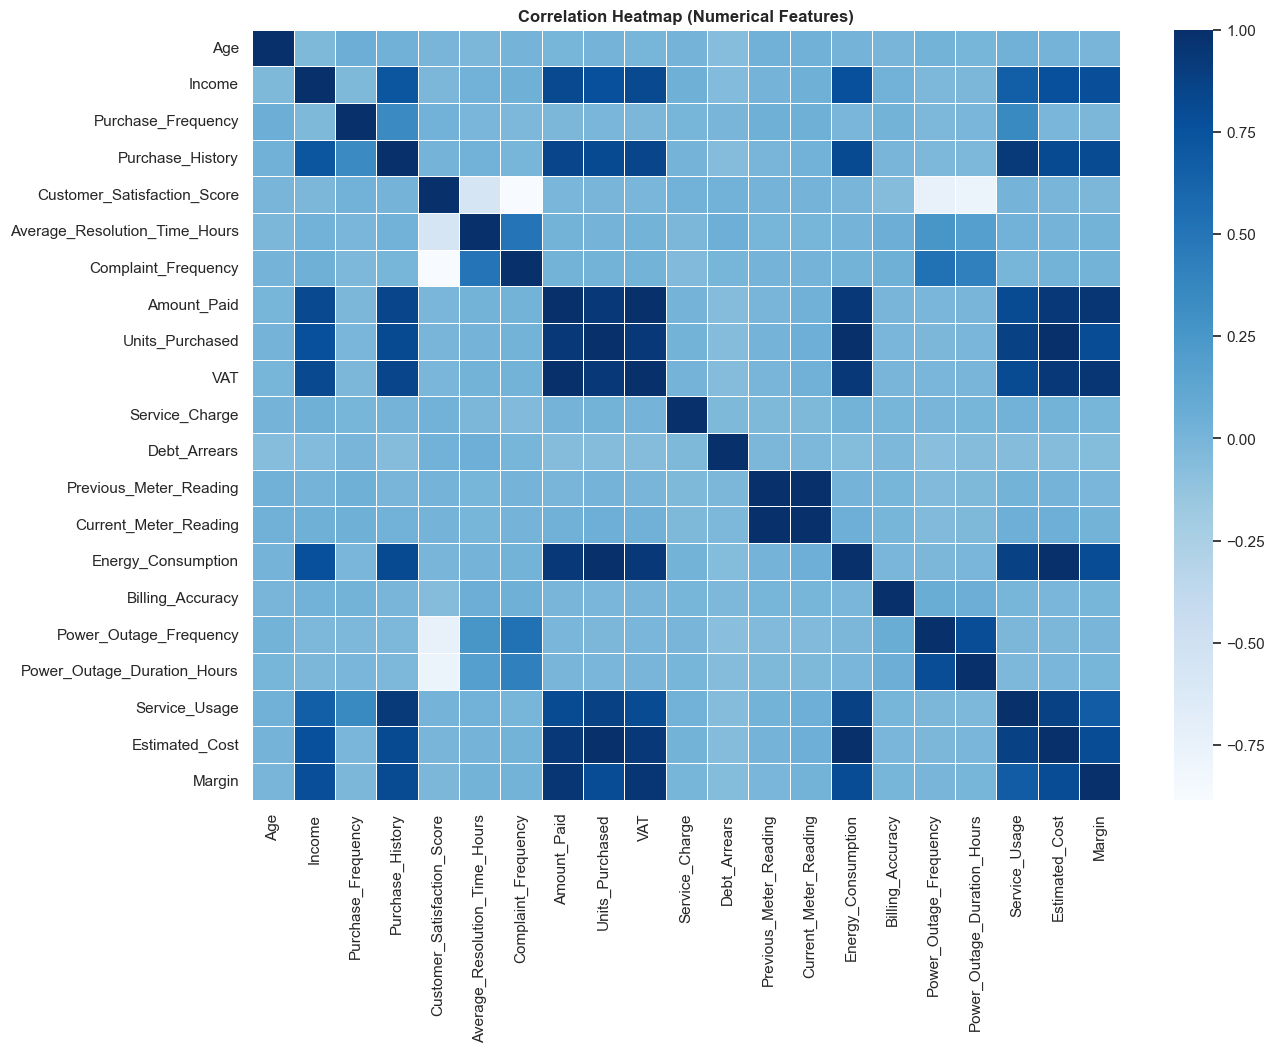

In [574]:
plt.figure(figsize=(14,10))
corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(corr, cmap="Blues", linewidths=0.5)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

Key relationships to look for:

Income vs Purchase_History (positive)

Outage Duration vs Complaints (positive)

Satisfaction vs Complaints (negative)

Debt vs Churn (positive)

Correlation helps identify:

strong drivers

redundant columns

## 5.FEATURE ENGINEERING

#### TARGET VARIABLE ENCODING

In [578]:
df["Churn"] = df["Churn_Status"].map({"No": 0, "Yes": 1})
df["Churn"].value_counts()

Churn
0    749
1    251
Name: count, dtype: int64

0 = Active customers
1 = churned customers

This is needed for machine learning.

Drop irrelevant columns.

In [580]:
df_model = df.drop(columns=[
    "Name", "Customer_ID", "Account_Number", "Meter_Number",
    "Transaction_Reference", "Receipt_Number", "Token",
    "Churn_Status", "Transaction_DateTime"
])

df_model.head()

,Age,Location,Income,Purchase_Frequency,Purchase_History,Customer_Satisfaction_Score,Average_Resolution_Time_Hours,Complaint_Frequency,Payment_Type,Meter_Type,...,Power_Outage_Duration_Hours,Service_Usage,Year,Month,Month_Name,Date,Estimated_Cost,Margin,Subscribed_Power_kVA,Churn
0,37,"Jabi, Abuja, Nigeria",67628,10,46405.95,4.79,11.70,0,POS,Prepaid,...,1.88,685.79,2025,11,November,2025-11-12,2671.2,1476.73,2,0
1,30,"Jabi, Abuja, Nigeria",115222,2,7270.59,4.23,18.26,2,POS,Postpaid,...,3.82,128.68,2025,4,April,2025-04-07,3020.8,1197.72,2,1
2,24,"Kurudu, Abuja, Nigeria",30000,6,9535.33,3.87,30.39,3,POS,Prepaid,...,4.62,20.00,2025,10,October,2025-10-27,540.4,751.07,2,0
3,30,"Jabi, Abuja, Nigeria",97539,9,67072.04,3.58,45.41,3,POS,Postpaid,...,7.38,613.26,2025,9,September,2025-09-13,3038.8,5842.78,2,0
4,25,"Gwarinpa, Abuja, Nigeria",70877,9,20027.24,4.15,53.70,1,Cash,Prepaid,...,2.23,144.24,2025,10,October,2025-10-06,868.4,1774.37,2,0


These columns are removed because:

IDs don't help prediction

they create noise in training

they can cause data leakage

#### ENCODE CATEGORICAL FEATURES

In [583]:
df_model = pd.get_dummies(df_model, drop_first=True)
df_model.head()

,Age,Income,Purchase_Frequency,Purchase_History,Customer_Satisfaction_Score,Average_Resolution_Time_Hours,Complaint_Frequency,Amount_Paid,Units_Purchased,VAT,...,Date_2026-03-16,Date_2026-03-17,Date_2026-03-18,Date_2026-03-19,Date_2026-03-20,Date_2026-03-21,Date_2026-03-23,Date_2026-03-24,Date_2026-03-25,Date_2026-03-26
0,37,67628,10,46405.95,4.79,11.70,0,4147.93,66.78,311.09,...,False,False,False,False,False,False,False,False,False,False
1,30,115222,2,7270.59,4.23,18.26,2,4218.52,75.52,316.39,...,False,False,False,False,False,False,False,False,False,False
2,24,30000,6,9535.33,3.87,30.39,3,1291.47,13.51,96.86,...,False,False,False,False,False,False,False,False,False,False
3,30,97539,9,67072.04,3.58,45.41,3,8881.58,75.97,666.12,...,False,False,False,False,False,False,False,False,False,False
4,25,70877,9,20027.24,4.15,53.70,1,2642.77,21.71,198.21,...,False,False,False,False,False,False,False,False,False,False


This converts text columns into numeric format:

Meter_Type

Tariff_Class

Payment_Type

Location

Month_Name

### 6 & 7 MODELLING & Evaluation

#### TRAIN-TEST SPLIT

In [ ]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### SCALE FEATURES (IMPORTANT FOR LOGISTIC REGRESSION)

In [593]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Scaling helps models like Logistic Regression because:

it improves convergence

prevents large features from dominating

### TRAIN LOGISTIC REGRESSION

In [595]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, log_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, log_pred))
print("\nClassification Report:\n", classification_report(y_test, log_pred))

Accuracy: 0.79

Confusion Matrix:
 [[126  15]
 [ 27  32]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.86       141
           1       0.68      0.54      0.60        59

    accuracy                           0.79       200
   macro avg       0.75      0.72      0.73       200
weighted avg       0.78      0.79      0.78       200



Accuracy shows overall correctness.

Confusion matrix shows:

True positives (correct churn prediction)

False positives (wrong churn prediction)
    
Classification report shows:
    
Precision (how correct churn predictions are)
    
Recall (how many churn customers were caught)

Recall is critical in churn because missing churn customers is costly.

### CONFUSION MATRIX VISUALIZATION 

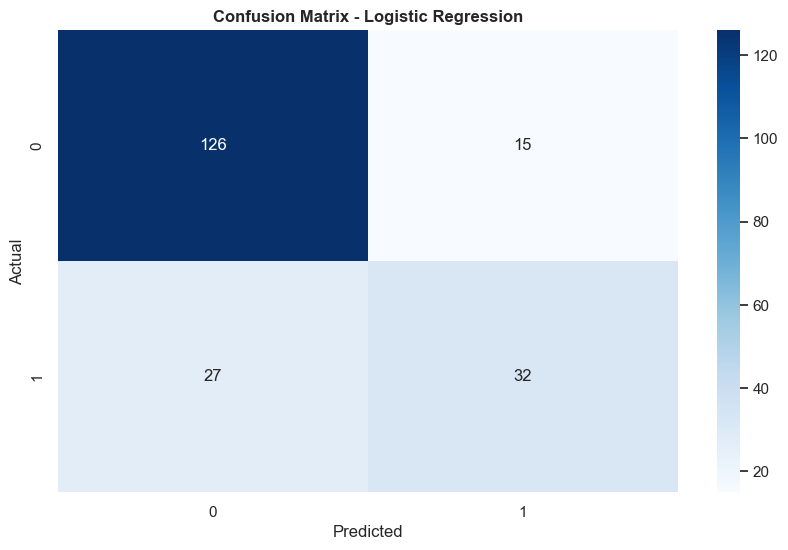

In [598]:
cm = confusion_matrix(y_test, log_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion matrix:

Top left = correctly predicted non-churn

Bottom right = correctly predicted churn

Bottom left = churn customers wrongly classified as non-churn (danger)

#### TRAIN RANDOM FOREST

In [601]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Accuracy: 0.88

Confusion Matrix:
 [[141   0]
 [ 24  35]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       141
           1       1.00      0.59      0.74        59

    accuracy                           0.88       200
   macro avg       0.93      0.80      0.83       200
weighted avg       0.90      0.88      0.87       200



Random Forest performs better because:

handles nonlinear relationships

captures interactions like outage + debt + satisfaction

### RANDOM FOREST CONFUSION MATRIX

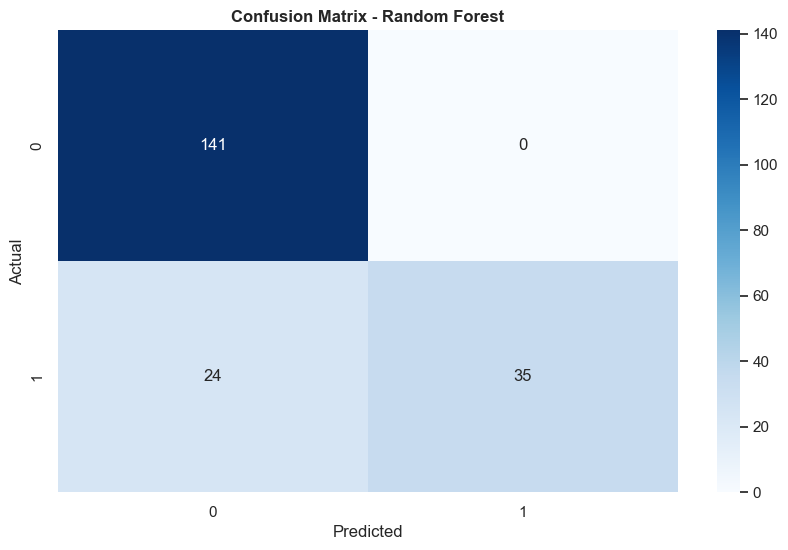

In [603]:
cm_rf = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### FEATURE IMPORTANCE (KEY FOR CX INSIGHT)

In [606]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

importances.head(10)

Debt_Arrears                   0.292467
Service_Charge                 0.027739
Previous_Meter_Reading         0.027501
Current_Meter_Reading          0.027221
VAT                            0.024767
Estimated_Cost                 0.024500
Units_Purchased                0.024315
Margin                         0.024053
Power_Outage_Duration_Hours    0.023649
Purchase_History               0.023408
dtype: float64

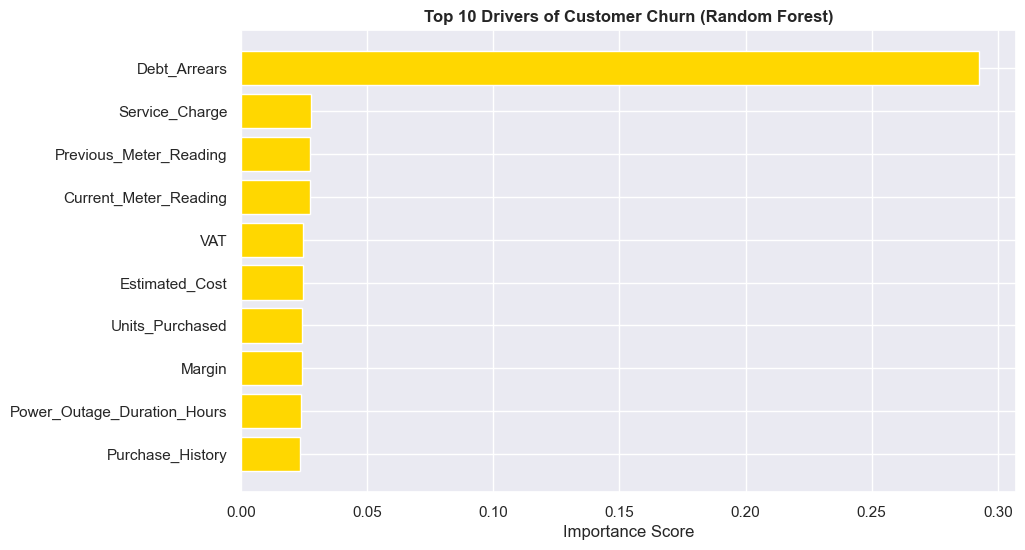

In [608]:
top10 = importances.head(10)

plt.barh(top10.index, top10.values, color=YELLOW)
plt.title("Top 10 Drivers of Customer Churn (Random Forest)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

This shows what affects churn most, typically:

Customer Satisfaction Score

Power Outage Duration

Complaint Frequency

Debt/Arrears

Resolution Time

## PROACTIVE RETENTION STRATEGIES

### IDENTIFY HIGH-RISK CUSTOMERS

In [610]:
df_results = df.copy()
df_results["Churn_Probability"] = rf_model.predict_proba(X)[:, 1]

df_results[["Customer_ID", "Location", "Income", "Debt_Arrears",
            "Customer_Satisfaction_Score", "Complaint_Frequency",
            "Power_Outage_Duration_Hours", "Churn_Probability"]].head()

,Customer_ID,Location,Income,Debt_Arrears,Customer_Satisfaction_Score,Complaint_Frequency,Power_Outage_Duration_Hours,Churn_Probability
0,CUST500000,"Jabi, Abuja, Nigeria",67628,12721.44,4.79,0,1.88,0.066667
1,CUST500001,"Jabi, Abuja, Nigeria",115222,12673.51,4.23,2,3.82,0.666667
2,CUST500002,"Kurudu, Abuja, Nigeria",30000,23076.67,3.87,3,4.62,0.073333
3,CUST500003,"Jabi, Abuja, Nigeria",97539,8620.57,3.58,3,7.38,0.026667
4,CUST500004,"Gwarinpa, Abuja, Nigeria",70877,6114.79,4.15,1,2.23,0.066667


### TOP 20 CUSTOMERS AT RISK OF CHURN

In [612]:
top_risk = df_results.sort_values("Churn_Probability", ascending=False).head(20)

top_risk[["Customer_ID", "Location", "Income", "Debt_Arrears",
          "Customer_Satisfaction_Score", "Complaint_Frequency",
          "Power_Outage_Frequency", "Power_Outage_Duration_Hours",
          "Churn_Probability"]]

,Customer_ID,Location,Income,Debt_Arrears,Customer_Satisfaction_Score,Complaint_Frequency,Power_Outage_Frequency,Power_Outage_Duration_Hours,Churn_Probability
532,CUST500532,"Lugbe, Abuja, Nigeria",30000,49341.56,3.41,3,7,13.36,0.910000
13,CUST500013,"Kurudu, Abuja, Nigeria",86429,64611.79,4.79,0,0,0.00,0.906667
474,CUST500474,"Kubwa, Abuja, Nigeria",44478,76416.25,4.56,0,2,1.10,0.903333
952,CUST500952,"Wuse, Abuja, Nigeria",52438,53487.79,3.80,3,3,7.05,0.900000
151,CUST500151,"Kurudu, Abuja, Nigeria",93911,46885.83,4.67,0,0,0.00,0.900000
553,CUST500553,"Maitama, Abuja, Nigeria",30000,40814.31,2.47,4,12,27.11,0.900000
730,CUST500730,"Apo, Abuja, Nigeria",100860,46826.36,3.74,4,3,1.94,0.896667
667,CUST500667,"Kurudu, Abuja, Nigeria",51555,57075.65,4.16,2,3,1.66,0.896667
243,CUST500243,"Apo, Abuja, Nigeria",123568,75885.47,3.16,3,7,17.34,0.896667
514,CUST500514,"Karu, Abuja, Nigeria",54490,60561.80,3.72,3,5,6.42,0.893333


These customers should be prioritized for retention.